# Intelligent Phishing Website Detection Using Machine Learning

# Part 1 – Project Introduction & Exploratory Data Analysis (EDA)

This notebook covers:

1. Project Introduction
2. Dataset Loading
3. Dataset Exploration
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Initial Observations

> Dataset: **PhiUSIIL_Phishing_URL_Dataset.csv**


## Problem Statement

Traditional blacklist-based phishing detection cannot identify newly created phishing websites. This notebook explores the PhiUSIIL dataset and prepares it for machine learning by performing detailed exploratory data analysis.


In [1]:
# ==========================
# Import Libraries
# ==========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"]=(8,5)
sns.set_style("whitegrid")


In [3]:
# ==========================
# Load Dataset
# ==========================
DATASET_PATH="PhiUSIIL_Phishing_URL_Dataset.csv"

df=pd.read_csv(DATASET_PATH)

print("Shape:",df.shape)
display(df.head())


Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:
# Dataset Information
display(df.info())
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

None

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [5]:
# Missing Values
missing=df.isnull().sum()
display(missing[missing>0])
print("Total Missing:",missing.sum())


Series([], dtype: int64)

Total Missing: 0


In [6]:
# Duplicate Rows
print("Duplicate Rows:",df.duplicated().sum())


Duplicate Rows: 0


label
1    134850
0    100945
Name: count, dtype: int64

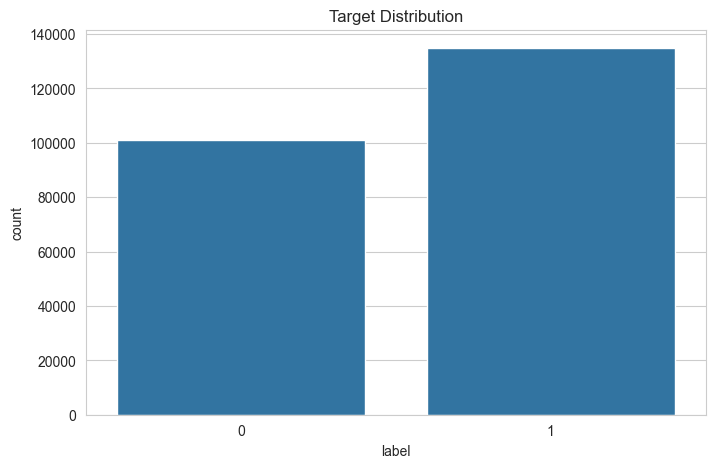

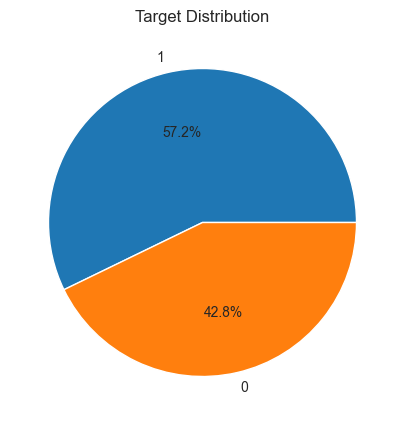

In [7]:
# Target Distribution
display(df["label"].value_counts())

sns.countplot(data=df,x="label")
plt.title("Target Distribution")
plt.show()

df["label"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Target Distribution")
plt.show()


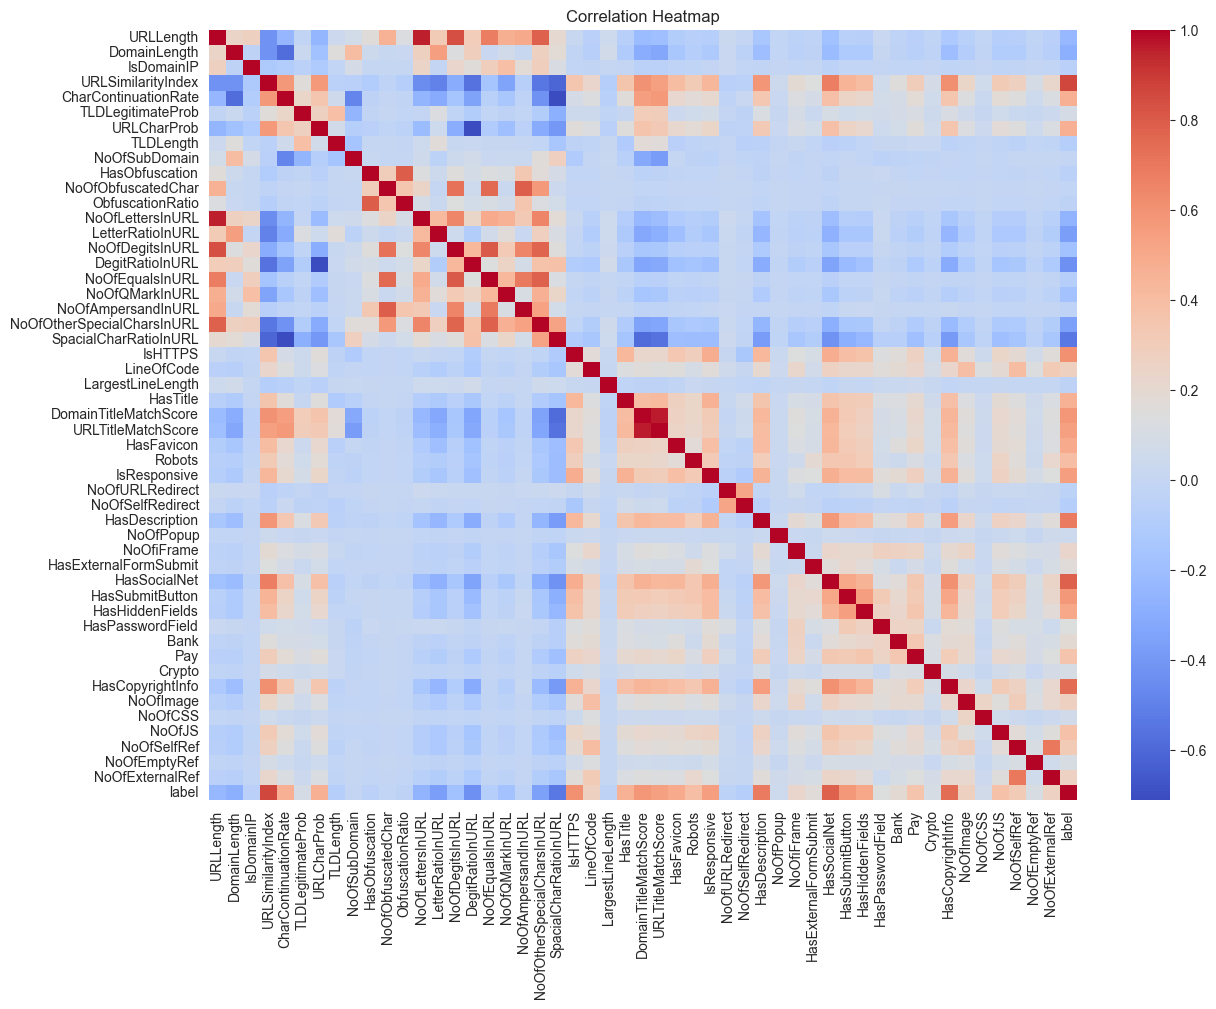

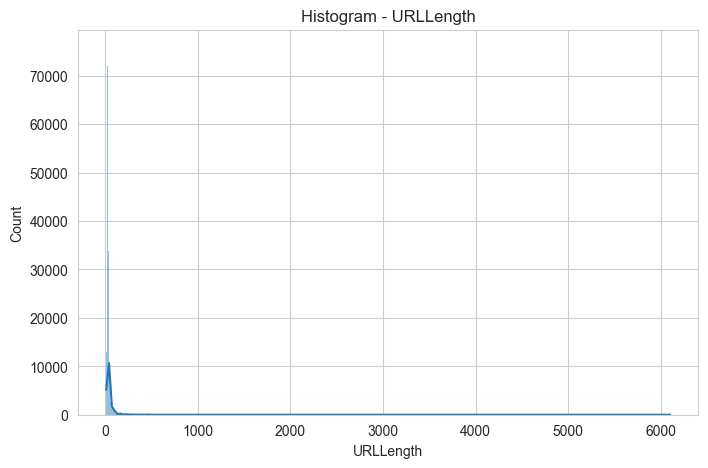

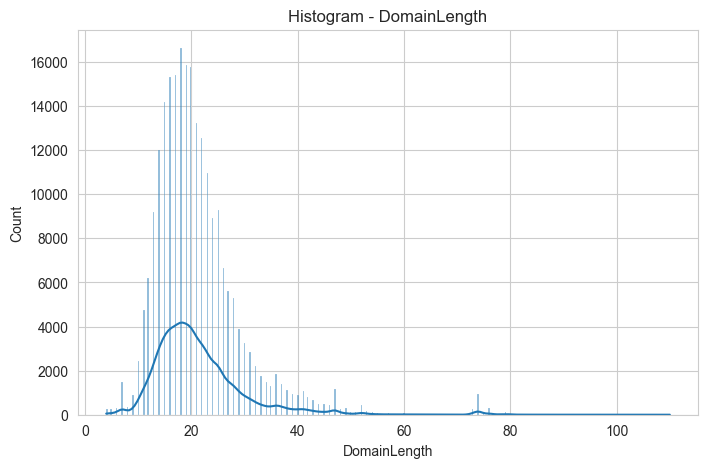

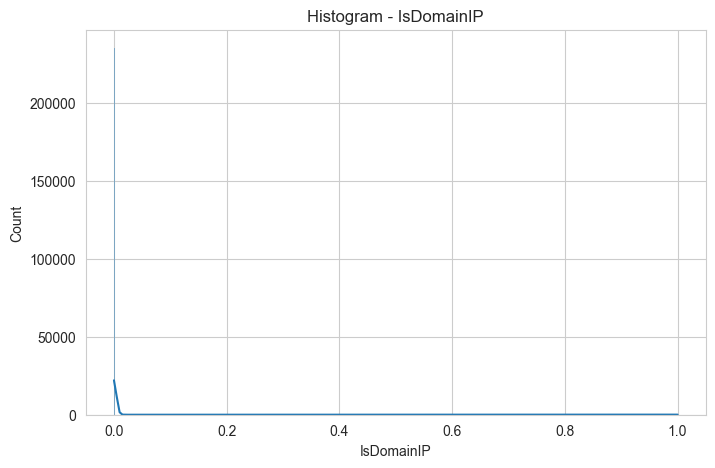

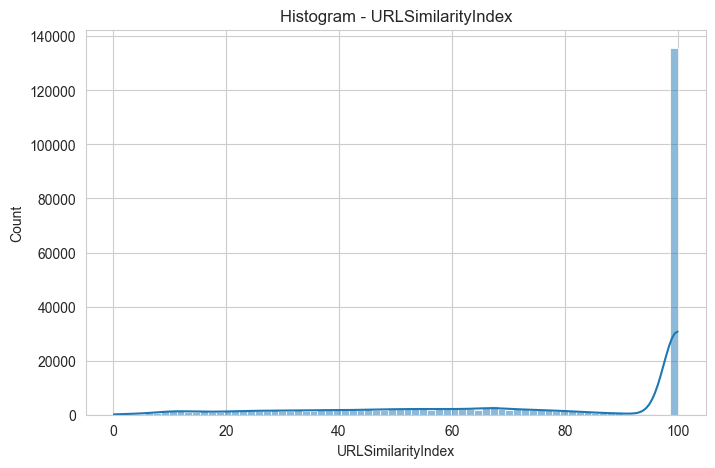

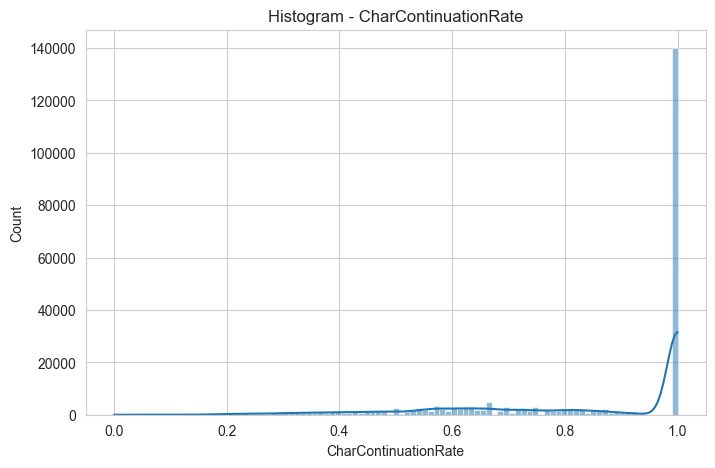

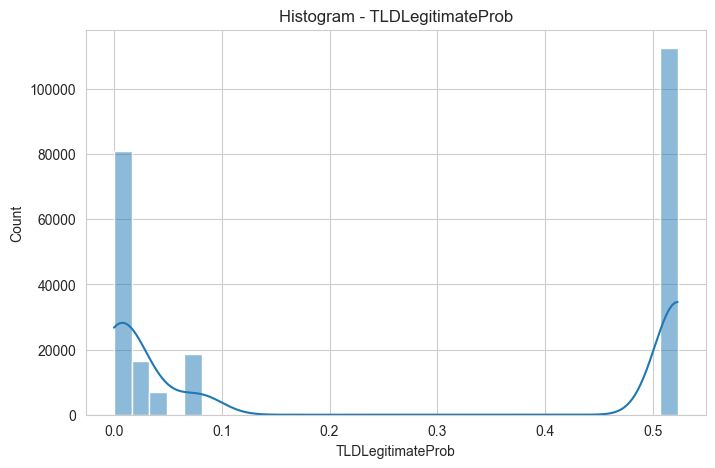

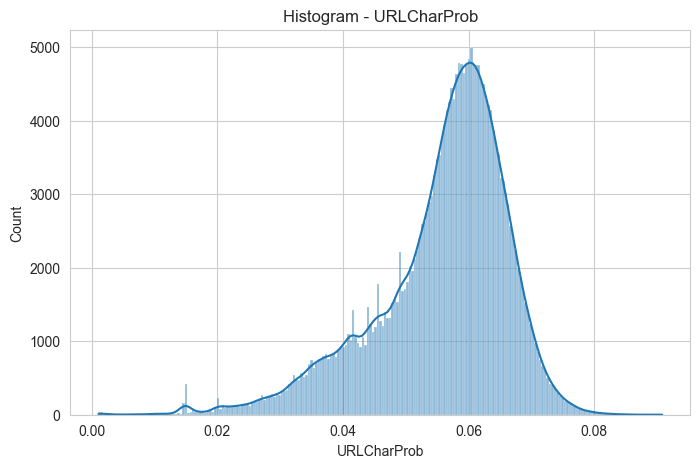

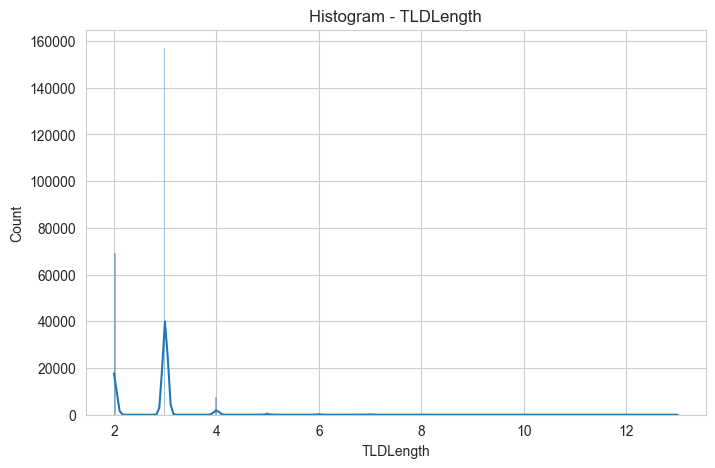

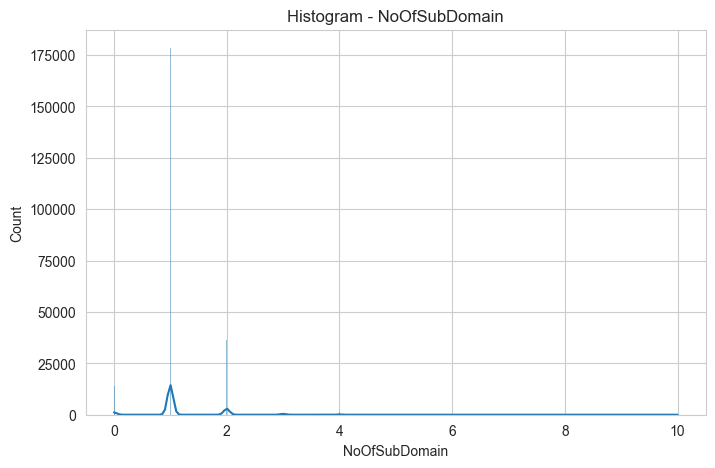

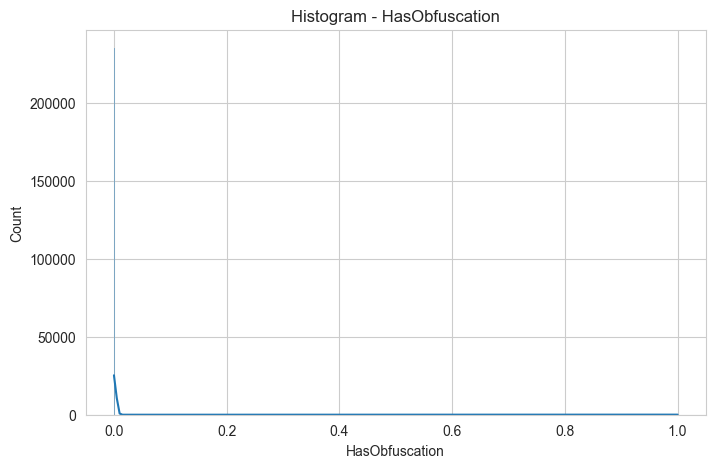

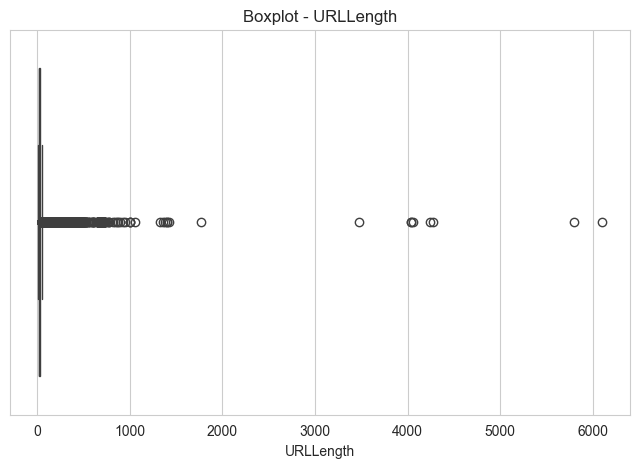

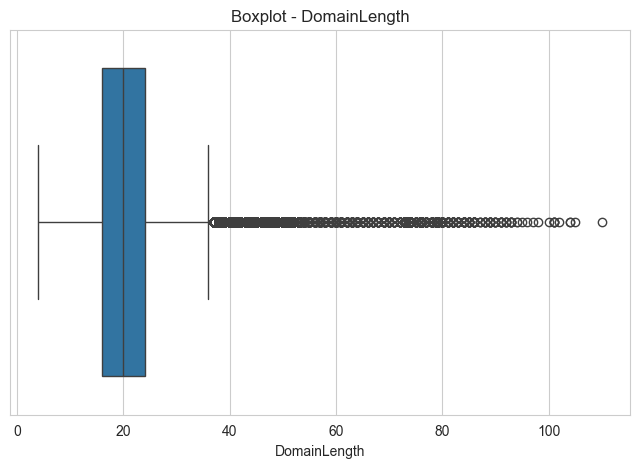

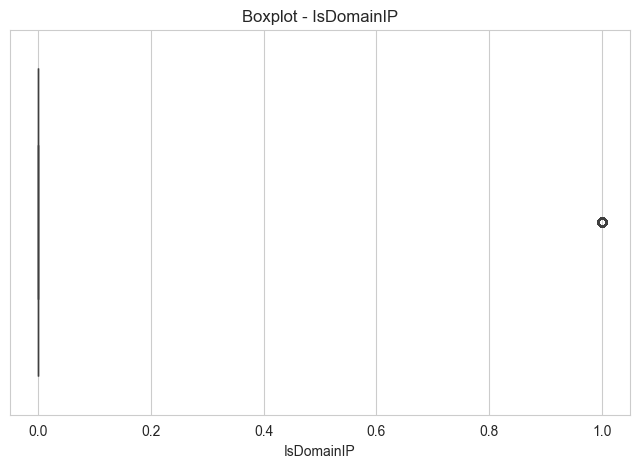

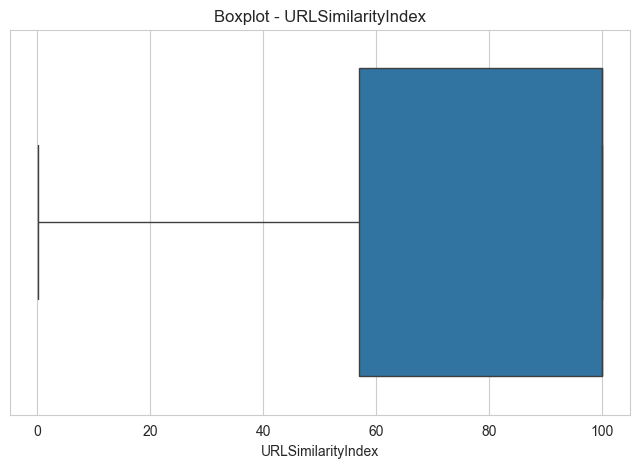

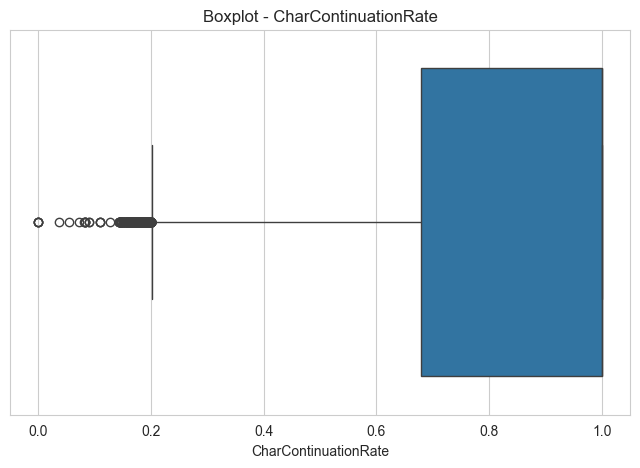

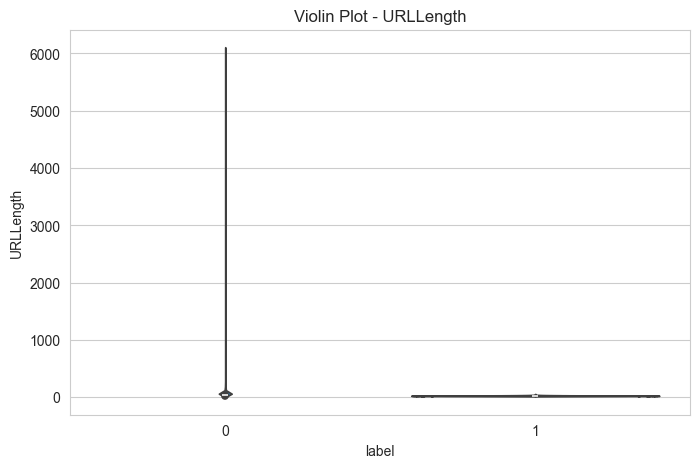

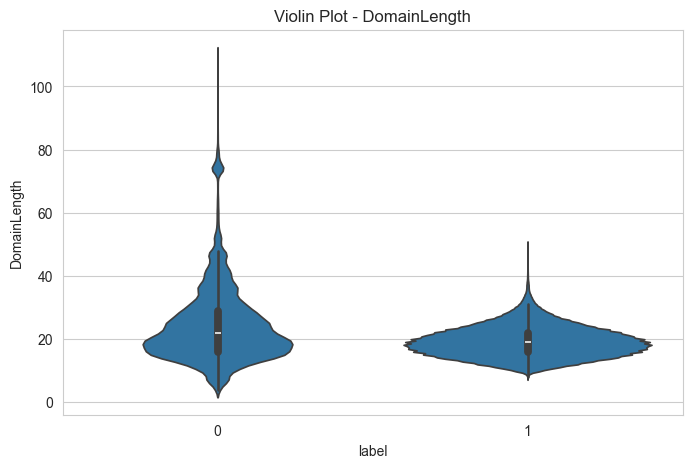

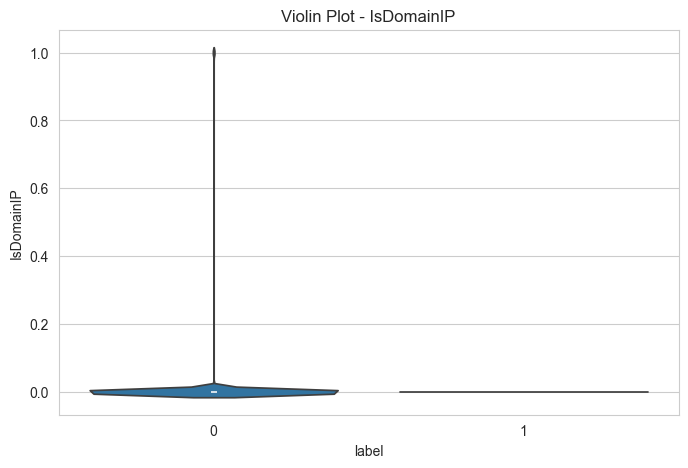

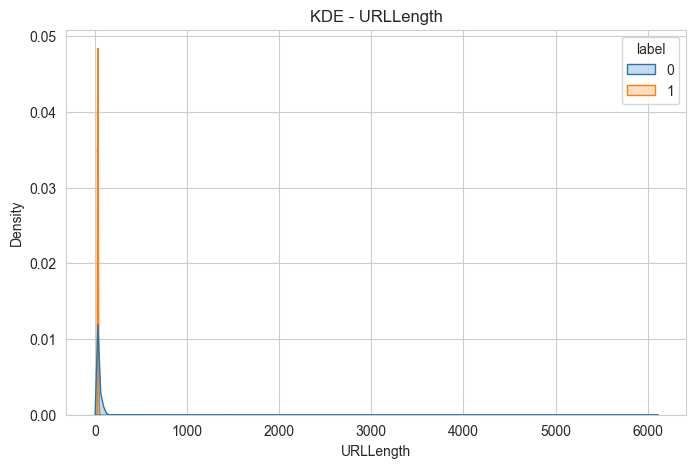

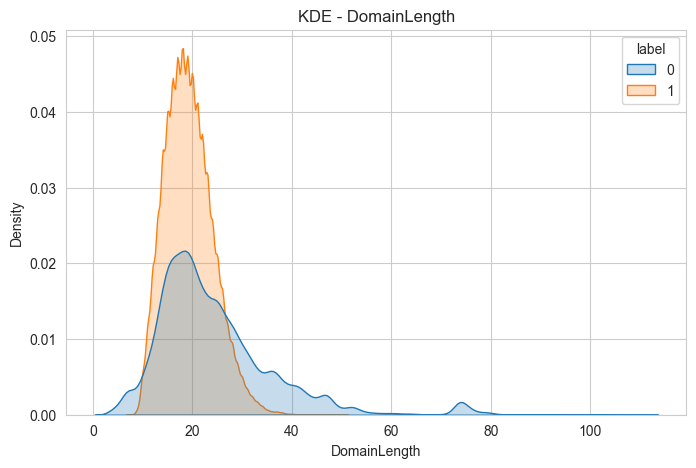

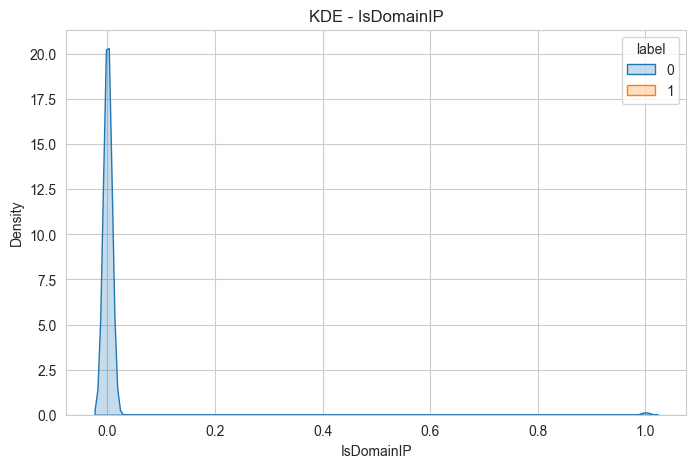

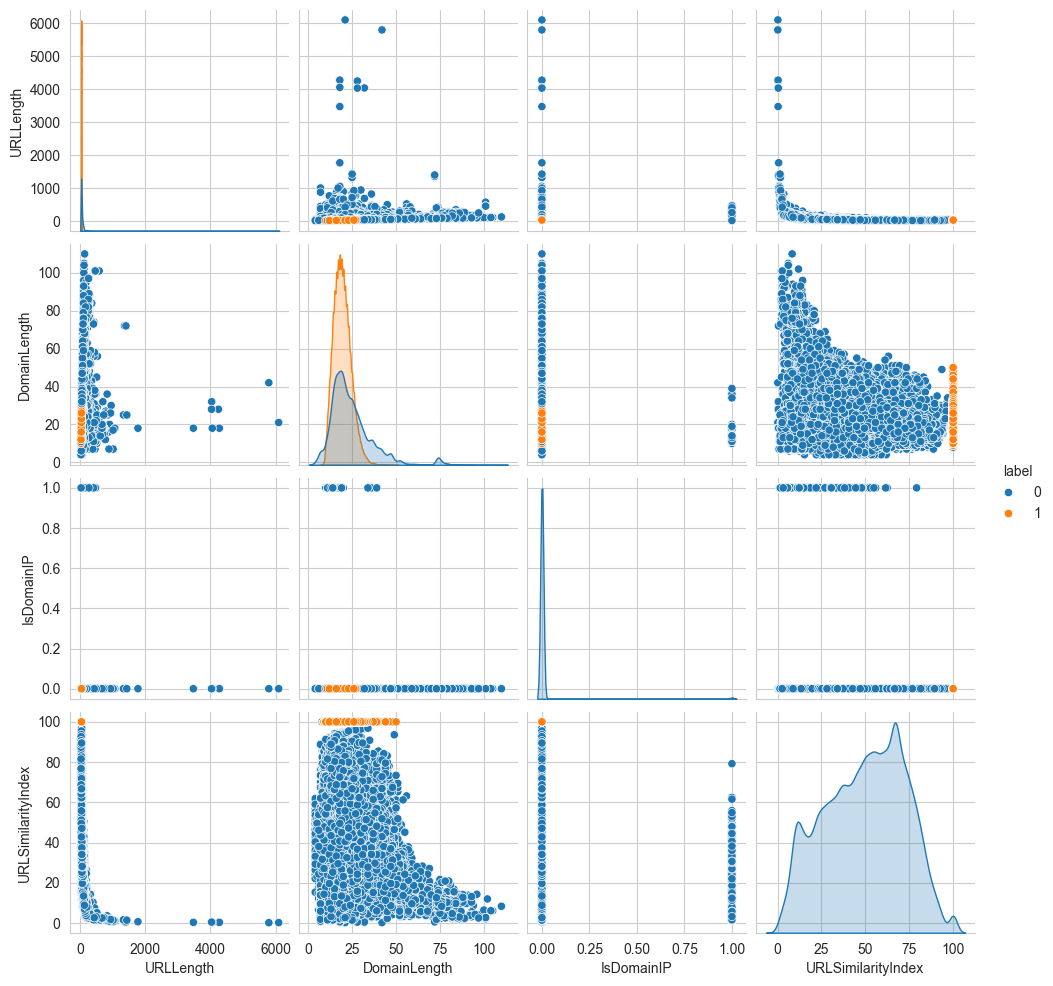

In [8]:
# ==========================
# Automatic EDA Visualizations
# ==========================

numeric=df.select_dtypes(include=np.number)

# 1 Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(numeric.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Select first 10 numeric features (excluding label if present)
features=[c for c in numeric.columns if c!="label"][:10]

# Histograms
for col in features:
    plt.figure()
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram - {col}")
    plt.show()

# Boxplots
for col in features[:5]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Violin plots
for col in features[:3]:
    plt.figure()
    sns.violinplot(x="label",y=col,data=df)
    plt.title(f"Violin Plot - {col}")
    plt.show()

# KDE plots
for col in features[:3]:
    plt.figure()
    sns.kdeplot(data=df,x=col,hue="label",fill=True)
    plt.title(f"KDE - {col}")
    plt.show()

# Pairplot
sns.pairplot(df[features[:4]+["label"]],hue="label")
plt.show()

# Plotly Interactive Histogram
fig=px.histogram(df,x=features[0],color="label",title="Interactive Histogram")
fig.show()


## Initial Observations

- Check whether the classes are balanced.
- Inspect correlations for redundant features.
- Identify skewed numerical features.
- Detect outliers using boxplots.
- Observe feature separation between phishing and legitimate classes.

The next notebook will cover preprocessing, feature engineering, and model training.
